前5行数据：
         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  texture_worst  perimeter_worst  area_worst  smo

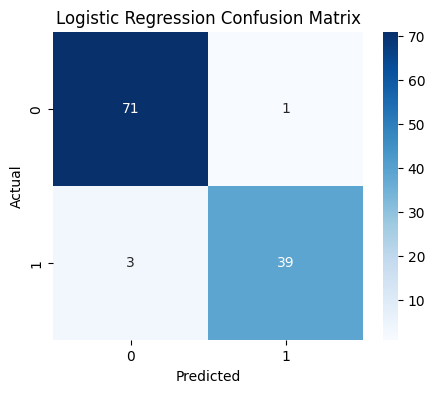



模型: KNN
Accuracy      : 0.9561
Precision     : 0.9744
Recall        : 0.9048
F1-score      : 0.9383
Training Time : 0.001523 秒

分类报告：
              precision    recall  f1-score   support

      Benign       0.95      0.99      0.97        72
   Malignant       0.97      0.90      0.94        42

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



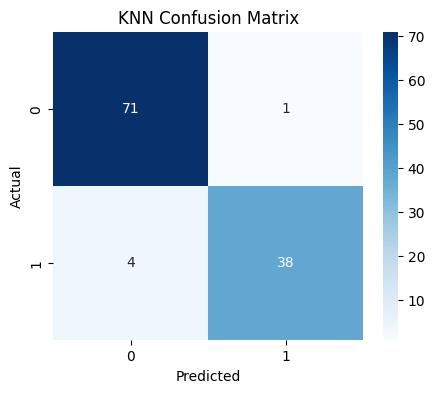



模型: Decision Tree
Accuracy      : 0.9298
Precision     : 0.9048
Recall        : 0.9048
F1-score      : 0.9048
Training Time : 0.015381 秒

分类报告：
              precision    recall  f1-score   support

      Benign       0.94      0.94      0.94        72
   Malignant       0.90      0.90      0.90        42

    accuracy                           0.93       114
   macro avg       0.92      0.92      0.92       114
weighted avg       0.93      0.93      0.93       114



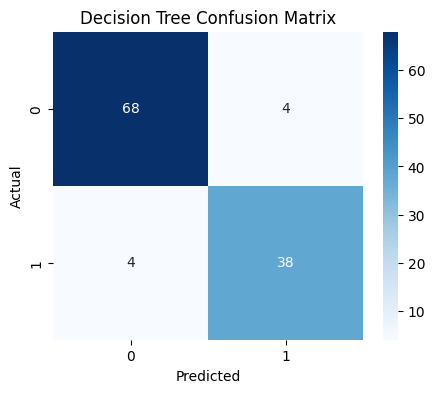



模型: Random Forest
Accuracy      : 0.9737
Precision     : 1.0000
Recall        : 0.9286
F1-score      : 0.9630
Training Time : 0.350076 秒

分类报告：
              precision    recall  f1-score   support

      Benign       0.96      1.00      0.98        72
   Malignant       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



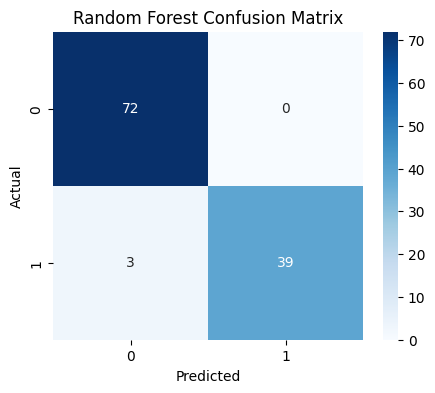



模型性能汇总
                 Model  Accuracy  Precision    Recall  F1-score  \
0  Logistic Regression  0.964912   0.975000  0.928571  0.951220   
1                  KNN  0.956140   0.974359  0.904762  0.938272   
2        Decision Tree  0.929825   0.904762  0.904762  0.904762   
3        Random Forest  0.973684   1.000000  0.928571  0.962963   

   Training Time(s)  
0          0.015857  
1          0.001523  
2          0.015381  
3          0.350076  


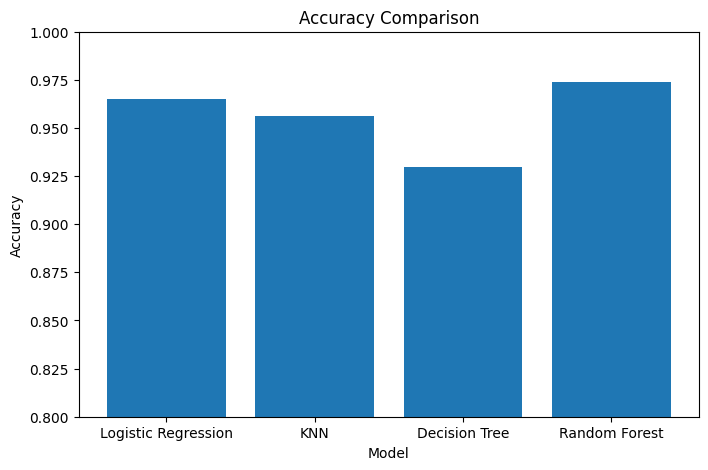

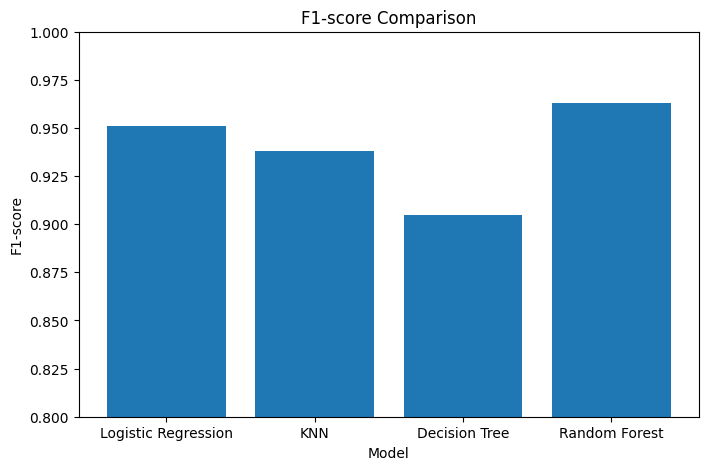


结果已保存到：model_comparison_results.csv


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# ==========================
# 1. 读取数据
# ==========================

data = pd.read_csv('breast cancer.csv')

print("前5行数据：")
print(data.head())

# ==========================
# 2. 删除全空列
# ==========================

data = data.dropna(axis=1, how='all')

# ==========================
# 3. 删除无用列
# ==========================

if 'id' in data.columns:
    data.drop(['id'], axis=1, inplace=True)

# ==========================
# 4. 检查空值
# ==========================

print("\n空值检查：")
print(data.isnull().sum())

# ==========================
# 5. 标签编码
# diagnosis:
# M(恶性)=1
# B(良性)=0
# ==========================

encoder = LabelEncoder()

data['diagnosis'] = encoder.fit_transform(
    data['diagnosis']
)

# ==========================
# 6. 特征与标签
# ==========================

X = data.drop('diagnosis', axis=1)
y = data['diagnosis']

# ==========================
# 7. 标准化
# ==========================

scaler = StandardScaler()

X = scaler.fit_transform(X)

# ==========================
# 8. 划分训练测试集
# ==========================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ==========================
# 9. 定义模型
# ==========================

models = {

    "Logistic Regression":
        LogisticRegression(max_iter=5000),

    "KNN":
        KNeighborsClassifier(n_neighbors=5),

    "Decision Tree":
        DecisionTreeClassifier(random_state=42),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=100,
            random_state=42
        )
}

# ==========================
# 10. 结果保存
# ==========================

results = []

accuracy_list = []
f1_list = []

# ==========================
# 11. 模型训练与测试
# ==========================

for name, model in models.items():

    print("\n")
    print("=" * 50)
    print("模型:", name)
    print("=" * 50)

    # ======================
    # 训练时间统计
    # ======================

    start_time = time.time()

    model.fit(X_train, y_train)

    end_time = time.time()

    training_time = end_time - start_time

    # ======================
    # 预测
    # ======================

    y_pred = model.predict(X_test)

    # ======================
    # 评价指标
    # ======================

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred
    )

    recall = recall_score(
        y_test,
        y_pred
    )

    f1 = f1_score(
        y_test,
        y_pred
    )

    accuracy_list.append(accuracy)
    f1_list.append(f1)

    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1,
        training_time
    ])

    # ======================
    # 输出指标
    # ======================

    print(f"Accuracy      : {accuracy:.4f}")
    print(f"Precision     : {precision:.4f}")
    print(f"Recall        : {recall:.4f}")
    print(f"F1-score      : {f1:.4f}")
    print(f"Training Time : {training_time:.6f} 秒")

    # ======================
    # 分类报告
    # ======================

    print("\n分类报告：")

    print(
        classification_report(
            y_test,
            y_pred,
            target_names=[
                'Benign',
                'Malignant'
            ]
        )
    )

    # ======================
    # 混淆矩阵
    # ======================

    cm = confusion_matrix(
        y_test,
        y_pred
    )

    plt.figure(figsize=(5, 4))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues'
    )

    plt.title(
        f'{name} Confusion Matrix'
    )

    plt.xlabel('Predicted')

    plt.ylabel('Actual')

    plt.show()

# ==========================
# 12. 结果汇总表
# ==========================

result_df = pd.DataFrame(
    results,
    columns=[
        'Model',
        'Accuracy',
        'Precision',
        'Recall',
        'F1-score',
        'Training Time(s)'
    ]
)

print("\n")
print("=" * 60)
print("模型性能汇总")
print("=" * 60)

print(result_df)

# ==========================
# 13. Accuracy对比图
# ==========================

plt.figure(figsize=(8, 5))

plt.bar(
    result_df['Model'],
    result_df['Accuracy']
)

plt.title(
    'Accuracy Comparison'
)

plt.ylabel(
    'Accuracy'
)

plt.xlabel(
    'Model'
)

plt.ylim(0.8, 1.0)

plt.show()

# ==========================
# 14. F1-score对比图
# ==========================

plt.figure(figsize=(8, 5))

plt.bar(
    result_df['Model'],
    result_df['F1-score']
)

plt.title(
    'F1-score Comparison'
)

plt.ylabel(
    'F1-score'
)

plt.xlabel(
    'Model'
)

plt.ylim(0.8, 1.0)

plt.show()

# ==========================
# 15. 保存结果CSV
# ==========================

result_df.to_csv(
    'model_comparison_results.csv',
    index=False
)

print("\n结果已保存到：model_comparison_results.csv")